# Getting Started with Non-Sequential Ray Tracing

This notebook introduces the core workflow of the Optiland non-sequential (NSQ) ray tracer.
In sequential ray tracing, rays travel through surfaces in a fixed order. In **non-sequential**
tracing, rays propagate freely through a scene, bouncing, refracting, and scattering on any
surface they encounter, in any order.

This makes NSQ tracing ideal for:
- Illumination design and uniformity analysis
- Stray light and ghost image analysis
- Scatter and diffuse surface modeling
- Non-imaging optics (concentrators, light pipes)

By the end of this notebook you will know how to:
1. Create an `NSQScene` and populate it with a source, a lens, and a detector
2. Run a Monte Carlo ray trace
3. Inspect the `SimulationResult` and visualize the irradiance map

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene,
    Spectrum,
    PointSourceConfig,
    LensConfig,
    IrradianceDetectorConfig,
)

## 1. Describing a Wavelength with `Spectrum`

Every NSQ source needs a `Spectrum` — a probability distribution over wavelengths
(in **micrometres**). The simplest case is monochromatic light:

In [2]:
# 550 nm = 0.55 µm — green light
spec = Spectrum.monochromatic(0.55)
print(f"Wavelength: {spec.wavelengths[0]:.3f} µm")

Wavelength: 0.550 µm


## 2. Building the Scene

An `NSQScene` contains three kinds of objects:
- **Sources** — emit rays into the scene
- **Components** — optical elements that redirect rays (lenses, mirrors)
- **Detectors** — record rays that hit them

Each object has a **`CoordinateSystem`** that defines its position and orientation.
All coordinates are in **millimetres**; rotations `rx`, `ry`, `rz` are in **radians**.

Here we set up a simple system:
```
Point source  →  Biconvex lens  →  Irradiance detector
   z = -100         z = 0              z = 92
```

Two choices in that layout are worth spelling out, because getting either wrong
is the most common way a first NSQ scene produces a meaningless picture.

**The source has to fit the lens.** A point source 100 mm from a lens with a
12.5 mm semi-diameter fills the aperture at `atan(12.5/100)` = 7.1°. Ask for a
wider cone and the surplus rays sail straight past the glass to the detector,
where they swamp the image with light that never went through the lens. We use
6°, which underfills the aperture slightly.

**The detector has to be at the image.** This lens has f = 49.1 mm, so an object
100 mm in front of it images to roughly 96 mm behind it. Spherical aberration
pulls the tightest spot slightly inside that, to about z = 92 mm. Put the
detector at, say, z = 200 mm instead and you measure a defocus blur.


In [3]:
scene = NSQScene()

# --- Source -----------------------------------------------------------------
# PointSource at z = -100 mm, emitting a 6-degree cone toward +z. At 100 mm
# that is a 10.5 mm beam radius, just inside the lens semi-diameter of 12.5 mm.
scene.add_source(
    'S1',
    CoordinateSystem(z=-100),
    PointSourceConfig(spectrum=spec, total_flux=1.0, half_angle_deg=6.0),
)

# --- Lens -------------------------------------------------------------------
# Biconvex N-BK7 lens at z = 0 mm
# r1 = 50 mm (front), r2 = -50 mm (back), center thickness = 5 mm
# semi-diameter = 12.5 mm
scene.add_lens(
    'L1',
    CoordinateSystem(z=0),
    LensConfig(r1=50, r2=-50, thickness=5, material='N-BK7', front_aperture_radius=12.5),
)

# --- Detector ---------------------------------------------------------------
# 4 x 4 mm irradiance detector at the image plane. Sized to the spot, not to
# the lens: the image is a few tenths of a millimetre across, so a 20 mm
# detector would spend 128 pixels resolving mostly empty space.
scene.add_detector(
    'D1',
    CoordinateSystem(z=92),
    IrradianceDetectorConfig(width=4, height=4, num_pixels_x=128, num_pixels_y=128),
)

print("Scene components:", scene.component_names)
print("Sources         :", scene.source_names)
print("Detectors       :", scene.detector_names)


Scene components: ['L1']
Sources         : ['S1']
Detectors       : ['D1']


### View the current scene

`scene.view()` draws a cross-section through the scene and overlays a sample of
traced rays. `color_by='bounce'` gives each leg of a ray path its own colour, so
you can see the beam enter the glass, leave it, and converge on the detector —
the non-sequential path, rather than a surface-by-surface list.


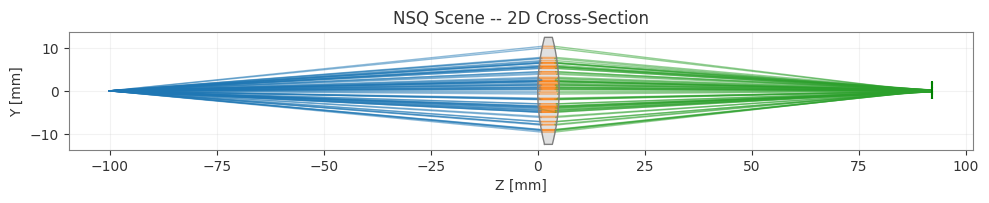

In [4]:
scene.view(num_rays=80, color_by='bounce')
plt.show()


## 3. Running the Monte Carlo Trace

`scene.trace()` launches the simulation. Key parameters:

| Parameter | Meaning | Default |
|---|---|---|
| `num_rays` | Total rays launched | — |
| `max_depth` | Maximum surface hits per ray | 16 |
| `min_flux_fraction` | Kill ray when flux drops below this fraction of initial | 1e-6 |
| `seed` | RNG seed for reproducibility | None |

A `SimulationResult` is returned with per-detector results and global statistics.

In [5]:
result = scene.trace(num_rays=100_000, seed=42)
print(f"Trace time          : {result.trace_time_sec:.2f} s")
print(f"Rays launched       : {result.num_rays_total:,}")
print(f"Rays on detector    : {result.detectors['D1'].num_rays_hit:,}")
print(f"Total flux in       : {result.total_flux_in:.4f} W")
print(f"Flux on detector    : {result.total_flux_detected:.4f} W")
print(f"Flux escaped        : {result.total_flux_escaped:.4f} W")
print(f"Flux conservation   : {result.flux_conservation_error:.2e} (relative error)")
print()
print("Most of the launched flux escapes: the source emits into a 6-degree cone")
print("but the detector is only 4 mm across, so it collects the image and")
print("nothing else. Flux conservation is the number to check, not the fraction")
print("landing on any one detector.")


Trace time          : 1.38 s
Rays launched       : 100,000
Rays on detector    : 91,746
Total flux in       : 1.0000 W
Flux on detector    : 0.9175 W
Flux escaped        : 0.0825 W
Flux conservation   : 6.94e-17 (relative error)

Most of the launched flux escapes: the source emits into a 6-degree cone
but the detector is only 4 mm across, so it collects the image and
nothing else. Flux conservation is the number to check, not the fraction
landing on any one detector.


## 4. Visualizing the Irradiance Map

Each detector in `result.detectors` holds a result object. For an
`IrradianceDetector` the result is an `IrradianceMap` with a `.plot()` method.

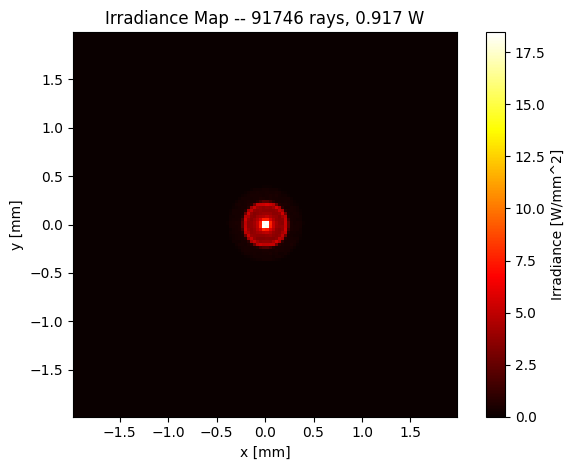

In [6]:
irr_map = result.detectors['D1']

fig = irr_map.plot(cmap='hot')
plt.tight_layout()
plt.show()

## 5. Inspecting the Raw Irradiance Array

`IrradianceMap.irradiance` is a 2-D NumPy array of shape `(ny, nx)` in W/mm².
You can compute statistics directly:

In [7]:
E = irr_map.irradiance
print(f"Array shape    : {E.shape}")
print(f"Peak irradiance: {E.max():.4f} W/mm²")
print(f"Mean irradiance: {E.mean():.6f} W/mm²")
print(f"Total flux     : {irr_map.total_flux:.4f} W")

Array shape    : (128, 128)
Peak irradiance: 18.4567 W/mm²
Mean irradiance: 0.057341 W/mm²
Total flux     : 0.9175 W


## 6. Cross-Section Plot

Take a horizontal slice through the centre of the irradiance map:

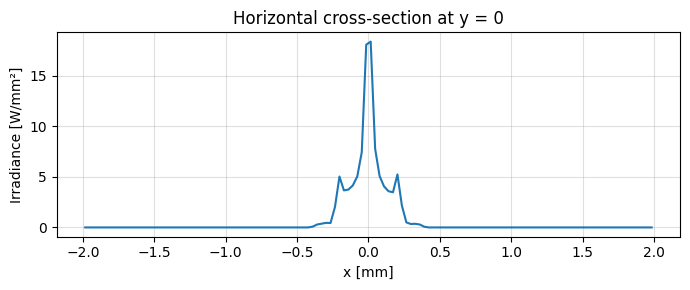

In [8]:
ny, nx = E.shape
centre_row = E[ny // 2, :]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(irr_map.x_coords, centre_row)
ax.set_xlabel('x [mm]')
ax.set_ylabel('Irradiance [W/mm²]')
ax.set_title('Horizontal cross-section at y = 0')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## Summary

The minimum NSQ workflow is:

```python
scene = NSQScene()
scene.add_source(name, cs, SourceConfig(...))
scene.add_lens(name, cs, LensConfig(...))
scene.add_detector(name, cs, DetectorConfig(...))
result = scene.trace(num_rays=N, seed=42)
result.detectors[name].plot()
```

Continue to the next notebooks to learn about the different source types,
component options, detectors, and advanced features.